# Image EDA, Preprocessing & Training Split Pipeline

## Comprehensive Metadata-First, Leak-Proof Pipeline

This notebook implements a strict **9-step linear pipeline** for image preprocessing, clinical label assignment, and training data preparation with zero patient-level data leakage.

### Pipeline Overview

**Phase 1: Setup, Loading & Filtering**
1. Load tabular checkpoint (df_merged) with PN_norm, Visit, side_right normalized
2. Load raw image manifest and extract PN_norm
2.1. **PN Filter**: Drop unmatchable images (PN_norm NOT in Excel)
2.2. **Raw EDA**: Analyze region distribution and raw image dimensions

**Phase 2: Metadata Extraction (Before Processing)**
3. Extract Visit via robust text mapping; compute capture_index to prevent overwrites

**Phase 3: Smart Preprocessing & Saving**
4. Apply preprocessing with:
   - **Hand Fix**: Largest contour only (ignore hands & reflections)
   - **Black Screen Fix**: Stricter visibility check (min 15%), spatial checks (60px min)
   - **Normalized Saving**: capture_index in filenames (e.g., PN_V1_ANT_C1_imgL.png)

**Phase 4: Strict Clinical Labeling**
5. Three-key left merge (PN_norm, Visit, side_right) + fillna(0) for missing knees

**Phase 5: Leak-Proof Splitting & Augmentation**
6. Define X (paths), y (labels), groups (PN_norm)
7. Patient-level GroupShuffleSplit (70%/10%/20% train/val/test) — NO leakage
8. Offline augmentation for minority class (train set only)
9. Export train_split.csv, val_split.csv, test_split.csv

Run cells **in order** from top to bottom.


---
## PHASE 1: SETUP, LOADING & FILTERING

### Step 1: Load Tabular Checkpoint

Load clinical data checkpoint and verify required columns: `PN`, `Visit`, `side_right`, `pain_label`.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import cv2
from PIL import Image
from pathlib import Path
import pickle
import re
from typing import Optional, Tuple

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the clinical tabular checkpoint
with open('cleaned_tabular_checkpoint.pkl', 'rb') as f:
    df_merged = pickle.load(f)

print(f"✓ Clinical data loaded: {len(df_merged)} rows")

# Verify required columns
required_cols = ['PN', 'Visit', 'side_right', 'pain_label']
missing_cols = [col for col in required_cols if col not in df_merged.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_merged: {missing_cols}")

# Verify column types
df_merged['Visit'] = pd.to_numeric(df_merged['Visit'], errors='coerce').astype('Int64')
df_merged['side_right'] = pd.to_numeric(df_merged['side_right'], errors='coerce').astype('Int64')

print(f"PN (unique): {df_merged['PN'].nunique()}")
print(f"Visit values: {sorted(df_merged['Visit'].dropna().unique())}")
print(f"side_right values: {sorted(df_merged['side_right'].dropna().unique())}")
print(f"pain_label values: {sorted(df_merged['pain_label'].dropna().unique())}")
print(f"\n✓ Step 1 complete: Tabular checkpoint loaded and verified")

✓ Clinical data loaded: 432 rows
PN (unique): 76
Visit values: [np.int64(1), np.int64(2), np.int64(3)]
side_right values: [np.int64(0), np.int64(1)]
pain_label values: [np.int64(0), np.int64(1)]

✓ Step 1 complete: Tabular checkpoint loaded and verified


---
### Step 2: Load Raw Images

Walk the raw Images/ directory and create initial manifest with file paths, region, and side.


In [3]:
# Walk the Images/ directory to gather all file paths
base_dir = Path('Images')
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
records = []

for img_path in base_dir.rglob('*'):
    if img_path.is_file() and img_path.suffix.lower() in image_extensions:
        try:
            # Extract basic metadata
            with Image.open(img_path) as img:
                width, height = img.size
            
            # Extract path components
            path_parts = list(img_path.parts)
            
            # Extract subject (folder immediately after Images/)
            subject = None
            if 'Images' in path_parts:
                images_index = path_parts.index('Images')
                if images_index + 1 < len(path_parts):
                    subject = path_parts[images_index + 1]
            
            # Extract region and side from path
            side = ''
            region = ''
            for part in path_parts:
                part_clean = str(part).strip().lower()
                
                if part_clean in ['l', 'r']:
                    side = part_clean.upper()
                
                # Normalize region naming
                if part_clean in ['ant', 'anterior']:
                    region = 'ANT'
                elif part_clean in ['post', 'posterior']:
                    region = 'POST'
                elif part_clean in ['lat', 'lateral', 'let']:
                    region = 'LAT'
                elif part_clean in ['med', 'medial']:
                    region = 'MED'
            
            records.append({
                'file_path': str(img_path),
                'file_name': img_path.name,
                'subject': subject,
                'region': region,
                'side': side,
                'width': width,
                'height': height
            })
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            continue

# Create source manifest
source_manifest = pd.DataFrame(records)

print(f"✓ Found {len(source_manifest)} images")
print(f"Subjects: {source_manifest['subject'].nunique()}")
print(f"Regions: {source_manifest['region'].value_counts().to_dict()}")
print(f"\n✓ Step 2 complete: Source manifest created with {len(source_manifest)} rows")
display(source_manifest.head(10))

✓ Found 1607 images
Subjects: 73
Regions: {'ANT': 468, 'MED': 314, '': 312, 'LAT': 309, 'POST': 204}

✓ Step 2 complete: Source manifest created with 1607 rows


,file_path,file_name,subject,region,side,width,height
0,Images/73-NY/73NY-9may18-Scale.JPG,73NY-9may18-Scale.JPG,73-NY,,,732,521
1,Images/63-NB/63NB-22mar18-Scale.JPG,63NB-22mar18-Scale.JPG,63-NB,,,729,491
2,Images/21-OD/21OD-Scale.JPG,21OD-Scale.JPG,21-OD,,,727,494
3,Images/74-ED/74ED-9may18-Scale.JPG,74ED-9may18-Scale.JPG,74-ED,,,731,491
4,Images/85-YS/85YS-9may18-Scale.JPG,85YS-9may18-Scale.JPG,85-YS,,,729,493
5,Images/70-EB/70EB-22mar18-Scale.JPG,70EB-22mar18-Scale.JPG,70-EB,,,731,491
6,Images/77-AA/77AA-9may18-Scale.JPG,77AA-9may18-Scale.JPG,77-AA,,,734,499
7,Images/69-IE/69IE-22mar18-Scale.JPG,69IE-22mar18-Scale.JPG,69-IE,,,731,491
8,Images/67-YH/67YH-22mar18-Scale.JPG,67YH-22mar18-Scale.JPG,67-YH,,,733,519
9,Images/82-OK/82OK-9may18-Scale.JPG,82OK-9may18-Scale.JPG,82-OK,,,723,493


---
## Step 2.1: Patient ID (PN) Overlap Check & Filtering

Extract PN_norm from the raw manifest and verify that images have corresponding clinical records. Filter out images whose patients are not in the Excel dataset.

In [4]:
# Define normalize_pn function (reused from Step 3, defined here for early use)
def normalize_pn(value):
    """Normalize patient ID to standard format."""
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().upper().replace('_', '-').replace(' ', '')
    text = re.sub(r'[^A-Z0-9-]', '', text)
    num_first = re.match(r'^(\d{1,3})-([A-Z]{1,4})$', text)
    if num_first:
        return f"{num_first.group(2)}-{num_first.group(1).zfill(2)}"
    return text


# Extract temporary PN_norm on source_manifest
source_manifest['PN_norm'] = source_manifest['subject'].apply(normalize_pn)

# Get unique PN values from both dataframes
pn_in_images = set(source_manifest['PN_norm'].dropna().unique())
pn_in_excel = set(df_merged['PN'].apply(normalize_pn).dropna().unique())

# Calculate overlap
overlap = pn_in_images & pn_in_excel
missing_from_excel = pn_in_images - pn_in_excel

# Print summary
print("="*70)
print("PATIENT ID (PN) OVERLAP ANALYSIS")
print("="*70)
print(f"Total unique PNs in Excel: {len(pn_in_excel)}")
print(f"Total unique PNs in Images: {len(pn_in_images)}")
print(f"Overlapping PNs: {len(overlap)}")
print(f"PNs in Images but NOT in Excel: {len(missing_from_excel)}")

if len(missing_from_excel) > 0:
    print(f"\nSample of PNs in Images missing from Excel (showing up to 20):")
    for pn in sorted(missing_from_excel)[:20]:
        count = (source_manifest['PN_norm'] == pn).sum()
        print(f"  - {pn}: {count} images")

# Filter source_manifest to keep only rows with PN_norm in Excel
original_count = len(source_manifest)
source_manifest = source_manifest[source_manifest['PN_norm'].isin(pn_in_excel)].reset_index(drop=True)
filtered_count = len(source_manifest)
dropped_count = original_count - filtered_count

print(f"\nFiltering Results:")
print(f"  Original images: {original_count}")
print(f"  Images kept (PN in Excel): {filtered_count}")
print(f"  Images dropped (PN not in Excel): {dropped_count}")
print(f"\n✓ Step 2.1 complete: Patient ID filtering done")

PATIENT ID (PN) OVERLAP ANALYSIS
Total unique PNs in Excel: 76
Total unique PNs in Images: 72
Overlapping PNs: 65
PNs in Images but NOT in Excel: 7

Sample of PNs in Images missing from Excel (showing up to 20):
  - AA-77: 17 images
  - AK-41: 16 images
  - EA-84: 17 images
  - EB-70: 17 images
  - LD-24: 22 images
  - SB-12: 49 images
  - TD-79: 17 images

Filtering Results:
  Original images: 1607
  Images kept (PN in Excel): 1452
  Images dropped (PN not in Excel): 155

✓ Step 2.1 complete: Patient ID filtering done


---
## Step 2.2: Raw Image EDA

Perform exploratory data analysis on the filtered raw images: region distribution, image count, and raw image dimension analysis.

RAW IMAGE EXPLORATORY DATA ANALYSIS

1. Images per anatomical region:
region
        276
ANT     425
LAT     282
MED     283
POST    186
Name: count, dtype: int64


/var/folders/h_/16c762vj27d0_xht2_6h85z40000gn/T/ipykernel_26928/2756691683.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=source_manifest, x='region', ax=ax, palette='Set2', order=['ANT', 'POST', 'LAT', 'MED'])


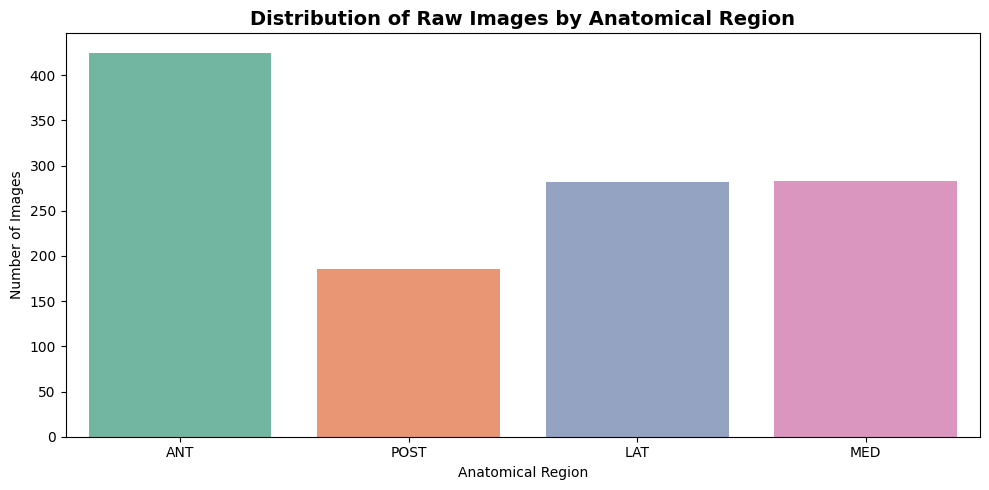


2. Raw image dimensions (sampling first 100 images):

Most common raw image sizes (from 100 sampled images):
  653x490: 64 images
  320x240: 9 images
  731x491: 3 images
  732x521: 2 images
  732x493: 1 images
  736x504: 1 images
  735x502: 1 images
  735x495: 1 images
  734x497: 1 images
  734x495: 1 images

Dimension statistics:
  Width  - Min: 320, Max: 739, Mean: 644
  Height - Min: 240, Max: 521, Mean: 470

✓ Step 2.2 complete: Raw image EDA done


In [5]:
# Import visualization libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns

# EDA on the filtered source_manifest
print("="*70)
print("RAW IMAGE EXPLORATORY DATA ANALYSIS")
print("="*70)

# 1. Count images per region
print("\n1. Images per anatomical region:")
region_counts = source_manifest['region'].value_counts().sort_index()
print(region_counts)

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=source_manifest, x='region', ax=ax, palette='Set2', order=['ANT', 'POST', 'LAT', 'MED'])
ax.set_title('Distribution of Raw Images by Anatomical Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Anatomical Region')
ax.set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

# 3. Sample first 100 images to read their dimensions
print("\n2. Raw image dimensions (sampling first 100 images):")
sample_size = min(100, len(source_manifest))
image_sizes = []

for idx in range(sample_size):
    row = source_manifest.iloc[idx]
    try:
        img_path = Path(row['file_path'])
        if img_path.exists():
            with Image.open(img_path) as img:
                width, height = img.size
                image_sizes.append((width, height))
    except Exception as e:
        pass

if image_sizes:
    # Convert to dataframe for analysis
    size_df = pd.DataFrame(image_sizes, columns=['width', 'height'])
    
    # Find most common sizes
    common_sizes = size_df.value_counts().head(10)
    print(f"\nMost common raw image sizes (from {len(image_sizes)} sampled images):")
    for (w, h), count in common_sizes.items():
        print(f"  {w}x{h}: {count} images")
    
    print(f"\nDimension statistics:")
    print(f"  Width  - Min: {size_df['width'].min()}, Max: {size_df['width'].max()}, Mean: {size_df['width'].mean():.0f}")
    print(f"  Height - Min: {size_df['height'].min()}, Max: {size_df['height'].max()}, Mean: {size_df['height'].mean():.0f}")

print(f"\n✓ Step 2.2 complete: Raw image EDA done")

---
## PHASE 2: METADATA EXTRACTION (BEFORE PROCESSING)

### Step 3: Extract Visit & Capture Index

Run normalization and feature extraction directly on the raw `source_manifest` dataframe before any heavy image preprocessing.


In [6]:
def normalize_pn(value):
    """Normalize patient ID to standard format."""
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().upper().replace('_', '-').replace(' ', '')
    text = re.sub(r'[^A-Z0-9-]', '', text)
    num_first = re.match(r'^(\d{1,3})-([A-Z]{1,4})$', text)
    if num_first:
        return f"{num_first.group(2)}-{num_first.group(1).zfill(2)}"
    return text


def extract_visit_number(file_path, file_name):
    """Extract visit number using robust text matching."""
    text = f"{file_path} {file_name}".lower()

    visit_map = {
        1: ['baseline', 'base', 'visit 0', 'visit0', 'v0'],
        2: ['fu 1', 'fu1', 'fu-1', 'f1', 'visit 1', 'visit1', 'v1', 'follow.up.1'],
        3: ['fu 3', 'fu3', 'fu-3', 'f3', 'visit 3', 'visit3', 'v3', 'follow.up.3'],
    }

    for visit_num, variants in visit_map.items():
        if any(variant in text for variant in variants):
            return visit_num

    return pd.NA


source_manifest['PN_norm'] = source_manifest['subject'].apply(normalize_pn)
source_manifest['Visit'] = source_manifest.apply(
    lambda row: extract_visit_number(row['file_path'], row['file_name']),
    axis=1,
)

unmapped_visits = source_manifest[source_manifest['Visit'].isna()].copy()
print(f"Raw images with valid Visit: {source_manifest['Visit'].notna().sum()}/{len(source_manifest)}")
print(f"Raw images with unmapped Visit: {len(unmapped_visits)}")

if len(unmapped_visits) > 0:
    print("Warning: dropping rows that cannot be assigned a Visit number before preprocessing.")
    display(unmapped_visits[['subject', 'file_name', 'file_path']].head(10))

source_manifest = source_manifest[source_manifest['Visit'].notna()].reset_index(drop=True)
source_manifest['Visit'] = source_manifest['Visit'].astype(int)

# Add per-capture index to prevent filename collisions for repeated region captures
source_manifest['capture_index'] = (
    source_manifest.groupby(['PN_norm', 'Visit', 'region']).cumcount() + 1
)
source_manifest['capture_index'] = source_manifest['capture_index'].astype(int)

print(f"\n✓ Step 3 complete: Feature extraction done on raw manifest")
print("Added capture_index per PN_norm + Visit + region")
display(source_manifest[['subject', 'PN_norm', 'file_name', 'region', 'side', 'Visit', 'capture_index']].head(15))

Raw images with valid Visit: 1395/1452
Raw images with unmapped Visit: 57


,subject,file_name,file_path
0,73-NY,73NY-9may18-Scale.JPG,Images/73-NY/73NY-9may18-Scale.JPG
1,63-NB,63NB-22mar18-Scale.JPG,Images/63-NB/63NB-22mar18-Scale.JPG
2,21-OD,21OD-Scale.JPG,Images/21-OD/21OD-Scale.JPG
3,74-ED,74ED-9may18-Scale.JPG,Images/74-ED/74ED-9may18-Scale.JPG
4,85-YS,85YS-9may18-Scale.JPG,Images/85-YS/85YS-9may18-Scale.JPG
5,69-IE,69IE-22mar18-Scale.JPG,Images/69-IE/69IE-22mar18-Scale.JPG
6,67-YH,67YH-22mar18-Scale.JPG,Images/67-YH/67YH-22mar18-Scale.JPG
7,82-OK,82OK-9may18-Scale.JPG,Images/82-OK/82OK-9may18-Scale.JPG
8,65-LM,65LM-22mar18-Scale.JPG,Images/65-LM/65LM-22mar18-Scale.JPG
9,18-GB,18GB-Scale.JPG,Images/18-GB/18GB-Scale.JPG



✓ Step 3 complete: Feature extraction done on raw manifest
Added capture_index per PN_norm + Visit + region


,subject,PN_norm,file_name,region,side,Visit,capture_index
0,75-YO,YO-75,75YO-9may18-Baseline-Knees_Anterior.tiff,ANT,,1,1
1,75-YO,YO-75,75YO-9may18-Baseline_post StepD-Knees_Anterior...,ANT,,1,2
2,75-YO,YO-75,75YO-9may18-Baseline_post StepD-Knee_Left_Ant....,ANT,,1,3
3,75-YO,YO-75,75YO-9may18-Baseline-Knee_Right_Ant.tiff,ANT,,1,4
4,75-YO,YO-75,75YO-9may18-Baseline-Knee_Left_Ant.tiff,ANT,,1,5
5,75-YO,YO-75,75YO-9may18-Baseline_post StepD-Knee_Right_Ant...,ANT,,1,6
6,75-YO,YO-75,75YO-9may18-Baseline-Knees_Posterior.tiff,POST,,1,1
7,75-YO,YO-75,75YO-9may18-Baseline_post StepD-Knees_Posterio...,POST,,1,2
8,75-YO,YO-75,75YO-9may18-Baseline_post StepD-Knee_Left_Lat....,LAT,L,1,1
9,75-YO,YO-75,75YO-9may18-Baseline-Knee_Left_Lat.tiff,LAT,L,1,2


---
## PHASE 3: SMART PREPROCESSING & SAVING

### Step 4: Preprocess, Split & Normalize

Iterate over the cleaned `source_manifest` with Hand Fix and Black Screen Fix. Save processed images (256×256) with capture_index in filenames to prevent overwrites.


In [ ]:
# === PREPROCESSING HELPER FUNCTIONS ===

def remove_logo(image_array, width_ratio=0.20, height_ratio=0.15):
    """Remove logo from top-left corner by masking with black."""
    image_array_copy = image_array.copy()
    h, w = image_array_copy.shape[:2]
    crop_h = int(h * height_ratio)
    crop_w = int(w * width_ratio)
    image_array_copy[0:crop_h, 0:crop_w] = (0, 0, 0)
    return image_array_copy


def remove_hair_dullrazor(image_array, kernel_size=(9, 9), threshold_val=20, inpaint_rad=2):
    """Remove hair using morphological operations and inpainting."""
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, threshold_val, 255, cv2.THRESH_BINARY)
    closing_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    hair_mask = cv2.morphologyEx(hair_mask, cv2.MORPH_CLOSE, closing_kernel)
    cleaned_image = cv2.inpaint(image_array, hair_mask, inpaint_rad, cv2.INPAINT_TELEA)
    return cleaned_image


def mask_background(image_array, threshold_val=15, min_area_ratio=0.01):
    """Isolate subject by masking background."""
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_array
    mask = np.zeros_like(gray)
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    for cnt in contours:
        if cv2.contourArea(cnt) > min_area:
            cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    result = cv2.bitwise_and(image_array, image_array, mask=mask)
    return result


def crop_to_subject(image_array, threshold_val=15, min_area_ratio=0.01):
    """
    THE HAND FIX: Crop to ONLY the single largest contour (the knee).
    Ignore hands, thermal reflections, and other artifacts by selecting max area blob.
    """
    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return image_array
    
    image_area = gray.shape[0] * gray.shape[1]
    min_area = image_area * min_area_ratio
    
    # Filter by minimum area
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    if not valid_contours:
        return image_array
    
    # THE FIX: Sort by area descending and take ONLY the largest contour
    valid_contours.sort(key=cv2.contourArea, reverse=True)
    largest_contour = valid_contours[0]
    
    # Get bounding box for this single largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Add small padding
    padding = 5
    y1 = max(0, y - padding)
    y2 = min(image_array.shape[0], y + h + padding)
    x1 = max(0, x - padding)
    x2 = min(image_array.shape[1], x + w + padding)
    
    return image_array[y1:y2, x1:x2]


def is_mostly_black(img_array, brightness_threshold=50, min_visible_ratio=0.15):
    """
    THE BLACK SCREEN FIX: Stricter visibility check + spatial checks for bad crops.
    - Requires min_visible_ratio=0.15 (15% of pixels must be bright)
    - Also flags if crop width or height < 60 pixels (degenerate crop)
    """
    # Spatial check first (fast)
    h, w = img_array.shape[:2]
    if h < 60 or w < 60:
        return True  # Too small, likely a bad crop
    
    # Brightness check
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY) if len(img_array.shape) == 3 else img_array
    visible_pixels = np.sum(gray > brightness_threshold)
    total_pixels = gray.size
    visibility_ratio = visible_pixels / total_pixels
    
    return visibility_ratio < min_visible_ratio


# Build processed images with normalized filenames
output_root = Path('Data/Images_Processed_Final')
output_root.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (256, 256)
processed_rows = []
errors = []

print(f"Processing {len(source_manifest)} filtered images with Hand & Black Screen fixes...\n")

for row_idx, row in source_manifest.iterrows():
    source_path = Path(row['file_path'])
    if not source_path.exists():
        errors.append({'row_idx': row_idx, 'error': 'Path not found', 'file': str(source_path)})
        continue

    try:
        img_bgr = cv2.imread(str(source_path))
        if img_bgr is None:
            raise ValueError("Could not load image")

        img_no_logo = remove_logo(img_bgr)
        img_no_hair = remove_hair_dullrazor(img_no_logo)
        img_masked = mask_background(img_no_hair)
        region = row['region']
        pn_norm = row['PN_norm']
        visit_num = int(row['Visit'])
        capture_index = int(row['capture_index'])

        if region in ['ANT', 'POST']:
            filename_lower = source_path.stem.lower()
            is_combined = any(marker in filename_lower for marker in ['both', 'bilateral', 'combined', 'bothlegs', 'twolegs'])

            if is_combined or pd.isna(row['side']) or row['side'] == '':
                gray = cv2.cvtColor(img_masked, cv2.COLOR_BGR2GRAY)
                width = gray.shape[1]
                start_x = int(width * 0.3)
                end_x = int(width * 0.7)
                col_brightness = np.sum(gray, axis=0)
                middle_valley = col_brightness[start_x:end_x]
                split_x = start_x + np.argmin(middle_valley)

                if split_x <= 0 or split_x >= width:
                    raise ValueError("Invalid split location")

                left_half_bgr = img_masked[:, :split_x]
                right_half_bgr = img_masked[:, split_x:]
                left_cropped = crop_to_subject(left_half_bgr)
                right_cropped = crop_to_subject(right_half_bgr)

                if is_mostly_black(left_cropped) or is_mostly_black(right_cropped):
                    raise ValueError("Split resulted in mostly black image (failed Black Screen check)")

                left_rgb = cv2.cvtColor(left_cropped, cv2.COLOR_BGR2RGB)
                right_rgb = cv2.cvtColor(right_cropped, cv2.COLOR_BGR2RGB)
                left_pil = Image.fromarray(left_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)
                right_pil = Image.fromarray(right_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)

                # NORMALIZED SAVING: Use capture_index in filename to prevent overwrites
                left_path = output_root / f"{pn_norm}_V{visit_num}_{region}_C{capture_index}_imgL.png"
                right_path = output_root / f"{pn_norm}_V{visit_num}_{region}_C{capture_index}_imgR.png"
                left_pil.save(left_path)
                right_pil.save(right_path)

                if region == 'ANT':
                    left_leg_side, right_leg_side = 'R', 'L'
                else:
                    left_leg_side, right_leg_side = 'L', 'R'

                left_rec = row.to_dict()
                left_rec.update({
                    'file_path': str(left_path),
                    'file_name': left_path.name,
                    'leg_side': left_leg_side,
                    'side_right': 1 if left_leg_side == 'R' else 0,
                    'is_split': True,
                })
                processed_rows.append(left_rec)

                right_rec = row.to_dict()
                right_rec.update({
                    'file_path': str(right_path),
                    'file_name': right_path.name,
                    'leg_side': right_leg_side,
                    'side_right': 1 if right_leg_side == 'R' else 0,
                    'is_split': True,
                })
                processed_rows.append(right_rec)
            else:
                img_cropped = crop_to_subject(img_masked)
                if is_mostly_black(img_cropped):
                    raise ValueError("Cropped image is mostly black (failed Black Screen check)")

                img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)
                img_pil = Image.fromarray(img_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)
                out_leg_side = row['side']
                out_path = output_root / f"{pn_norm}_V{visit_num}_{region}_{out_leg_side}_C{capture_index}.png"
                img_pil.save(out_path)

                rec = row.to_dict()
                rec.update({
                    'file_path': str(out_path),
                    'file_name': out_path.name,
                    'leg_side': out_leg_side,
                    'side_right': 1 if out_leg_side == 'R' else 0,
                    'is_split': False,
                })
                processed_rows.append(rec)
        elif region in ['LAT', 'MED']:
            img_cropped = crop_to_subject(img_masked)
            if is_mostly_black(img_cropped):
                raise ValueError("Cropped image is mostly black (failed Black Screen check)")

            img_rgb = cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)
            img_pil = Image.fromarray(img_rgb).resize(TARGET_SIZE, Image.Resampling.BILINEAR)
            out_leg_side = row['side']
            out_path = output_root / f"{pn_norm}_V{visit_num}_{region}_{out_leg_side}_C{capture_index}.png"
            img_pil.save(out_path)

            rec = row.to_dict()
            rec.update({
                'file_path': str(out_path),
                'file_name': out_path.name,
                'leg_side': out_leg_side,
                'side_right': 1 if out_leg_side == 'R' else 0,
                'is_split': False,
            })
            processed_rows.append(rec)

    except Exception as e:
        errors.append({'row_idx': row_idx, 'error': str(e), 'file': str(source_path)})

    if (row_idx + 1) % 100 == 0:
        print(f"Processed {row_idx + 1}/{len(source_manifest)}...")

df_processed = pd.DataFrame(processed_rows).reset_index(drop=True)

print(f"\n" + "="*70)
print("STEP 4: PREPROCESSING COMPLETE")
print("="*70)
print(f"Input: {len(source_manifest)} images")
print(f"Output: {len(df_processed)} processed images (256×256)")
print(f"Errors/Skipped: {len(errors)}")
print(f"\nApplied fixes:")
print(f"  ✓ Hand Fix: Largest contour only (ignores artifacts)")
print(f"  ✓ Black Screen Fix: min_visible_ratio=15%, spatial checks (60px min)")
print(f"  ✓ Normalized Saving: capture_index in filenames prevents overwrites")
print(f"  ✓ Strict 256×256 resizing")

if len(errors) > 0:
    print(f"\nSample errors:")
    for err in errors[:5]:
        print(f"  Row {err['row_idx']}: {err['error']}")

display(df_processed.head(10))


Processing 1395 cleaned images...

Processed 100/1395...
Processed 200/1395...
Processed 300/1395...
Processed 400/1395...
Processed 500/1395...
Processed 600/1395...
Processed 700/1395...
Processed 800/1395...
Processed 900/1395...
Processed 1000/1395...
Processed 1100/1395...
Processed 1200/1395...
Processed 1300/1395...

✓ Processing complete:
  Input: 1395 images
  Output: 1649 processed images
  Errors: 69

✓ Step 4 complete: Preprocessing, splitting, and normalized saving done


,file_path,file_name,subject,region,side,width,height,PN_norm,Visit,capture_index,leg_side,side_right,is_split
0,Data/Images_Processed_Final/YO-75_V1_ANT_C2_im...,YO-75_V1_ANT_C2_imgL.png,75-YO,ANT,,653,490,YO-75,1,2,R,1,True
1,Data/Images_Processed_Final/YO-75_V1_ANT_C2_im...,YO-75_V1_ANT_C2_imgR.png,75-YO,ANT,,653,490,YO-75,1,2,L,0,True
2,Data/Images_Processed_Final/YO-75_V1_ANT_C3_im...,YO-75_V1_ANT_C3_imgL.png,75-YO,ANT,,653,490,YO-75,1,3,R,1,True
3,Data/Images_Processed_Final/YO-75_V1_ANT_C3_im...,YO-75_V1_ANT_C3_imgR.png,75-YO,ANT,,653,490,YO-75,1,3,L,0,True
4,Data/Images_Processed_Final/YO-75_V1_ANT_C4_im...,YO-75_V1_ANT_C4_imgL.png,75-YO,ANT,,653,490,YO-75,1,4,R,1,True
5,Data/Images_Processed_Final/YO-75_V1_ANT_C4_im...,YO-75_V1_ANT_C4_imgR.png,75-YO,ANT,,653,490,YO-75,1,4,L,0,True
6,Data/Images_Processed_Final/YO-75_V1_ANT_C5_im...,YO-75_V1_ANT_C5_imgL.png,75-YO,ANT,,653,490,YO-75,1,5,R,1,True
7,Data/Images_Processed_Final/YO-75_V1_ANT_C5_im...,YO-75_V1_ANT_C5_imgR.png,75-YO,ANT,,653,490,YO-75,1,5,L,0,True
8,Data/Images_Processed_Final/YO-75_V1_ANT_C6_im...,YO-75_V1_ANT_C6_imgL.png,75-YO,ANT,,653,490,YO-75,1,6,R,1,True
9,Data/Images_Processed_Final/YO-75_V1_ANT_C6_im...,YO-75_V1_ANT_C6_imgR.png,75-YO,ANT,,653,490,YO-75,1,6,L,0,True


---
## PHASE 4: STRICT CLINICAL LABELING

### Step 5: Three-Key Merge + Missing Knee Fix

Merge processed images with clinical data using exactly three keys: `PN_norm`, `Visit`, `side_right`. Apply Missing Knee Fix: fillna(0) for unlabeled knees.


In [8]:
# Prepare image dataframe for merge
img = df_processed.copy()

# Use the binary side_right value already created in Step 4; fall back to leg_side only if needed
if 'side_right' not in img.columns:
    img['side_right'] = img['leg_side'].map({'R': 1, 'L': 0})
else:
    img['side_right'] = pd.to_numeric(img['side_right'], errors='coerce')

img = img[img['side_right'].notna()].reset_index(drop=True)
img['side_right'] = img['side_right'].astype(int)

print(f"Images ready for merge: {len(img)}")
print(f"Images with R leg: {(img['side_right']==1).sum()}")
print(f"Images with L leg: {(img['side_right']==0).sum()}")

Images ready for merge: 1649
Images with R leg: 828
Images with L leg: 821


In [9]:
# Prepare clinical dataframe for merge
clin = df_merged[['PN', 'Visit', 'side_right', 'pain_label']].copy()

# Normalize PN in clinical data
clin['PN_norm'] = clin['PN'].apply(normalize_pn)

# Ensure proper types
clin = clin.dropna(subset=['PN_norm', 'Visit', 'side_right'])
clin['Visit'] = clin['Visit'].astype(int)
clin['side_right'] = clin['side_right'].astype(int)

# Keep only required columns
clin = clin[['PN_norm', 'Visit', 'side_right', 'pain_label']].copy()
clin = clin.drop_duplicates()

print(f"Clinical records for merging: {len(clin)}")
print(f"Unique PN: {clin['PN_norm'].nunique()}")
print(f"Unique PN-Visit pairs: {clin.drop_duplicates(subset=['PN_norm', 'Visit']).shape[0]}")

Clinical records for merging: 432
Unique PN: 76
Unique PN-Visit pairs: 217


In [ ]:
# === STEP 5: THREE-KEY MERGE WITH MISSING KNEE FIX ===

# THE THREE-KEY MERGE (STRICT)
# This guarantees each image's leg gets the correct clinical label using exactly three keys

df_labeled = img.merge(
    clin,
    on=['PN_norm', 'Visit', 'side_right'],
    how='left'
)

# Keep track of how many labels were missing before filling
matched_before_fill = df_labeled['pain_label'].notna().sum()
unmatched_before_fill = df_labeled['pain_label'].isna().sum()

# THE MISSING KNEE FIX: Fill missing pain labels with 0 for unlabeled / presumed healthy knees
# Rationale: If a patient exists in Excel but has no specific row for this knee/side,
# we assume the knee is healthy (Class 0) rather than discarding the image.
df_labeled['pain_label'] = df_labeled['pain_label'].fillna(0).astype(int)

print("="*70)
print("STEP 5: STRICT THREE-KEY MERGE + MISSING KNEE FIX")
print("="*70)
print(f"\nThree-key merge on: ['PN_norm', 'Visit', 'side_right']")
print(f"Images with clinical records (direct match): {matched_before_fill}")
print(f"Images without direct clinical record (fillna→0): {unmatched_before_fill}")
print(f"Total labeled images: {len(df_labeled)}")

print(f"\nPain label distribution after fillna(0):")
print(df_labeled['pain_label'].value_counts(dropna=False).sort_index())

print(f"\n✓ Step 5 complete: Three-key merge + Missing Knee Fix applied")

# Display sample labeled rows
display_cols = ['subject', 'file_name', 'region', 'leg_side', 'side_right', 'Visit', 'PN_norm', 'pain_label']
display_cols = [c for c in display_cols if c in df_labeled.columns]
display(df_labeled[display_cols].head(20))


IMAGE LABELING SUMMARY (Strict Three-Key Merge)

Images with clinical records: 1475
Images without clinical records before fill: 174
Total: 1649

Pain label distribution after fill:
pain_label
0     460
1    1189
Name: count, dtype: int64

✓ Step 5 complete: Three-key merge completed
  Missing pain labels were filled with 0


,subject,file_name,region,leg_side,side_right,Visit,PN_norm,pain_label
0,75-YO,YO-75_V1_ANT_C2_imgL.png,ANT,R,1,1,YO-75,0
1,75-YO,YO-75_V1_ANT_C2_imgR.png,ANT,L,0,1,YO-75,1
2,75-YO,YO-75_V1_ANT_C3_imgL.png,ANT,R,1,1,YO-75,0
3,75-YO,YO-75_V1_ANT_C3_imgR.png,ANT,L,0,1,YO-75,1
4,75-YO,YO-75_V1_ANT_C4_imgL.png,ANT,R,1,1,YO-75,0
5,75-YO,YO-75_V1_ANT_C4_imgR.png,ANT,L,0,1,YO-75,1
6,75-YO,YO-75_V1_ANT_C5_imgL.png,ANT,R,1,1,YO-75,0
7,75-YO,YO-75_V1_ANT_C5_imgR.png,ANT,L,0,1,YO-75,1
8,75-YO,YO-75_V1_ANT_C6_imgL.png,ANT,R,1,1,YO-75,0
9,75-YO,YO-75_V1_ANT_C6_imgR.png,ANT,L,0,1,YO-75,1


---
## PHASE 5: LEAK-PROOF SPLITTING & AUGMENTATION

### Step 6: Export Labeled Manifest

Filter to rows with valid `pain_label` and export as `labeled_image_manifest.csv`.


In [11]:
# Keep all labeled rows for export
# Missing pain labels were already filled with 0 in Step 5
df_final = df_labeled.reset_index(drop=True)

print(f"\nFinal labeled dataset: {len(df_final)} images")
print(f"Rows with pain_label == 0: {(df_final['pain_label']==0).sum()}")
print(f"Rows with pain_label == 1: {(df_final['pain_label']==1).sum()}")

# Summary by region
print(f"\nBreakdown by region:")
print(df_final['region'].value_counts())

# Summary by class
print(f"\nBreakdown by class:")
print(df_final['pain_label'].value_counts().sort_index())

# Subjects
print(f"\nUnique subjects: {df_final['subject'].nunique()}")


Final labeled dataset: 1649 images
Rows with pain_label == 0: 460
Rows with pain_label == 1: 1189

Breakdown by region:
region
ANT     728
POST    356
MED     283
LAT     282
Name: count, dtype: int64

Breakdown by class:
pain_label
0     460
1    1189
Name: count, dtype: int64

Unique subjects: 66


In [12]:
# Export the labeled manifest
export_path = Path('labeled_image_manifest.csv')

# Select columns to export
export_cols = [
    'subject', 'PN_norm', 'file_name', 'file_path',
    'region', 'leg_side', 'side_right', 'Visit', 'capture_index',
    'pain_label', 'width', 'height'
]
export_cols = [c for c in export_cols if c in df_final.columns]

df_export = df_final[export_cols].copy()
df_export.to_csv(export_path, index=False)

print(f"\n" + "="*70)
print(f"MANIFEST EXPORTED SUCCESSFULLY")
print(f"="*70)
print(f"\nFile: {export_path}")
print(f"Rows: {len(df_export)}")
print(f"Columns: {list(export_cols)}")

print(f"\n✓ Step 6 complete: Pipeline finished")
print(f"\nFinal statistics:")
print(f"  Total images: {len(df_export)}")
print(f"  Class 0 (No pain): {(df_export['pain_label']==0).sum()}")
print(f"  Class 1 (Pain): {(df_export['pain_label']==1).sum()}")
print(f"  Unique subjects: {df_export['subject'].nunique()}")

display(df_export.head(20))


MANIFEST EXPORTED SUCCESSFULLY

File: labeled_image_manifest.csv
Rows: 1649
Columns: ['subject', 'PN_norm', 'file_name', 'file_path', 'region', 'leg_side', 'side_right', 'Visit', 'capture_index', 'pain_label', 'width', 'height']

✓ Step 6 complete: Pipeline finished

Final statistics:
  Total images: 1649
  Class 0 (No pain): 460
  Class 1 (Pain): 1189
  Unique subjects: 66


,subject,PN_norm,file_name,file_path,region,leg_side,side_right,Visit,capture_index,pain_label,width,height
0,75-YO,YO-75,YO-75_V1_ANT_C2_imgL.png,Data/Images_Processed_Final/YO-75_V1_ANT_C2_im...,ANT,R,1,1,2,0,653,490
1,75-YO,YO-75,YO-75_V1_ANT_C2_imgR.png,Data/Images_Processed_Final/YO-75_V1_ANT_C2_im...,ANT,L,0,1,2,1,653,490
2,75-YO,YO-75,YO-75_V1_ANT_C3_imgL.png,Data/Images_Processed_Final/YO-75_V1_ANT_C3_im...,ANT,R,1,1,3,0,653,490
3,75-YO,YO-75,YO-75_V1_ANT_C3_imgR.png,Data/Images_Processed_Final/YO-75_V1_ANT_C3_im...,ANT,L,0,1,3,1,653,490
4,75-YO,YO-75,YO-75_V1_ANT_C4_imgL.png,Data/Images_Processed_Final/YO-75_V1_ANT_C4_im...,ANT,R,1,1,4,0,653,490
5,75-YO,YO-75,YO-75_V1_ANT_C4_imgR.png,Data/Images_Processed_Final/YO-75_V1_ANT_C4_im...,ANT,L,0,1,4,1,653,490
6,75-YO,YO-75,YO-75_V1_ANT_C5_imgL.png,Data/Images_Processed_Final/YO-75_V1_ANT_C5_im...,ANT,R,1,1,5,0,653,490
7,75-YO,YO-75,YO-75_V1_ANT_C5_imgR.png,Data/Images_Processed_Final/YO-75_V1_ANT_C5_im...,ANT,L,0,1,5,1,653,490
8,75-YO,YO-75,YO-75_V1_ANT_C6_imgL.png,Data/Images_Processed_Final/YO-75_V1_ANT_C6_im...,ANT,R,1,1,6,0,653,490
9,75-YO,YO-75,YO-75_V1_ANT_C6_imgR.png,Data/Images_Processed_Final/YO-75_V1_ANT_C6_im...,ANT,L,0,1,6,1,653,490


---
### Step 6.5 (Prep): Define X, y, and Groups

Prepare data structures for leak-proof splitting.


In [ ]:
### STEP 6.5: PREPARATION OF X, y, AND GROUPS

# Load labeled manifest if not already in memory
df_images_labeled = df_export.copy()

# Filter to ensure no missing pain_label
df_images_labeled = df_images_labeled[df_images_labeled['pain_label'].notna()].reset_index(drop=True)

# Define X, y, and groups for sklearn
X = df_images_labeled['file_path'].values
y = df_images_labeled['pain_label'].values
groups = df_images_labeled['PN_norm'].values

print("="*70)
print("STEP 6.5: PREPARATION OF X, y, AND GROUPS")
print("="*70)
print(f"Total samples: {len(X)}")
print(f"Unique patients (groups): {len(set(groups))}")
print(f"Class distribution:")
print(f"  Class 0 (No pain): {(y == 0).sum()}")
print(f"  Class 1 (Pain): {(y == 1).sum()}")
print(f"\n✓ X (file paths), y (labels), and groups (PN_norm) defined")


STEP 7.1: PREPARATION OF X AND y
Total samples: 1649
Unique patients (groups): 65
Class distribution:
  Class 0 (No pain): 460
  Class 1 (Pain): 1189

✓ X, y, and groups defined


In [ ]:
### STEP 7: PATIENT-LEVEL SPLIT (LEAK-PROOF, 70%/10%/20%)

from sklearn.model_selection import GroupShuffleSplit

print("="*70)
print("STEP 7: LEAK-PROOF PATIENT-LEVEL SPLIT")
print("="*70)
print("\nCritical Rule: Each patient (PN_norm) must belong to ONLY ONE set.")
print("Using GroupShuffleSplit to enforce this at the group level.\n")

# Create a numeric group mapping (required for GroupShuffleSplit)
unique_groups = np.unique(groups)
group_to_idx = {g: i for i, g in enumerate(unique_groups)}
groups_numeric = np.array([group_to_idx[g] for g in groups])

# First split: Train_Val (80%) and Test (20%) - use PN_norm as groups
print("Split 1: Train_Val (80%) vs Test (20%)...")
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss1.split(X, y, groups_numeric))

X_train_val, X_test = X[train_val_idx], X[test_idx]
y_train_val, y_test = y[train_val_idx], y[test_idx]
groups_train_val = groups[train_val_idx]
groups_test = groups[test_idx]

# Create numeric groups for train_val split
groups_train_val_unique = np.unique(groups_train_val)
group_to_idx_tv = {g: i for i, g in enumerate(groups_train_val_unique)}
groups_train_val_numeric = np.array([group_to_idx_tv[g] for g in groups_train_val])

# Second split: Train (87.5% of 80% = 70% total) and Val (12.5% of 80% = 10% total)
print("Split 2: Train (87.5% of 80% = 70% total) vs Val (12.5% of 80% = 10% total)...")
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val_numeric))

X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]
groups_train = groups_train_val[train_idx]
groups_val = groups_train_val[val_idx]

# Get unique patient counts
unique_train = len(np.unique(groups_train))
unique_val = len(np.unique(groups_val))
unique_test = len(np.unique(groups_test))

# Check for ZERO overlap (CRITICAL)
train_patients = set(np.unique(groups_train))
val_patients = set(np.unique(groups_val))
test_patients = set(np.unique(groups_test))

overlap_tv = train_patients & val_patients
overlap_tt = train_patients & test_patients
overlap_vt = val_patients & test_patients

print(f"\n" + "="*70)
print("SPLIT RESULTS (WITH LEAK CHECK)")
print("="*70)

print(f"\nTrain Set:")
print(f"  Total samples: {len(X_train)}")
print(f"  Unique patients: {unique_train}")
print(f"  Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")

print(f"\nVal Set:")
print(f"  Total samples: {len(X_val)}")
print(f"  Unique patients: {unique_val}")
print(f"  Class 0: {(y_val == 0).sum()}, Class 1: {(y_val == 1).sum()}")

print(f"\nTest Set:")
print(f"  Total samples: {len(X_test)}")
print(f"  Unique patients: {unique_test}")
print(f"  Class 0: {(y_test == 0).sum()}, Class 1: {(y_test == 1).sum()}")

print(f"\n" + "="*70)
print("DATA LEAKAGE CHECK (CRITICAL)")
print("="*70)
print(f"Patients in BOTH Train and Val: {len(overlap_tv)}")
print(f"Patients in BOTH Train and Test: {len(overlap_tt)}")
print(f"Patients in BOTH Val and Test: {len(overlap_vt)}")

if len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0:
    print("\n✓✓✓ ZERO OVERLAP - NO DATA LEAKAGE DETECTED! ✓✓✓")
else:
    print("\n✗✗✗ WARNING: DATA LEAKAGE DETECTED! ✗✗✗")

# Store indices for later use
train_indices = np.where(df_images_labeled['PN_norm'].isin(train_patients))[0]
val_indices = np.where(df_images_labeled['PN_norm'].isin(val_patients))[0]
test_indices = np.where(df_images_labeled['PN_norm'].isin(test_patients))[0]

df_train = df_images_labeled.iloc[train_indices].reset_index(drop=True)
df_val = df_images_labeled.iloc[val_indices].reset_index(drop=True)
df_test = df_images_labeled.iloc[test_indices].reset_index(drop=True)

print(f"\n✓ Step 7 complete: Patient-level leak-proof split done")


STEP 7.2: PATIENT-LEVEL SPLIT (NO DATA LEAKAGE)

Train Set:
  Total samples: 1141
  Unique patients: 45
  Class 0: 331, Class 1: 810

Val Set:
  Total samples: 198
  Unique patients: 7
  Class 0: 59, Class 1: 139

Test Set:
  Total samples: 310
  Unique patients: 13
  Class 0: 70, Class 1: 240

Data Leakage Check (CRITICAL):
  Patients in BOTH Train and Val: 0
  Patients in BOTH Train and Test: 0
  Patients in BOTH Val and Test: 0
  ✓ ZERO OVERLAP - No data leakage detected!

✓ Step 7.2 complete: Patient-level split done


In [ ]:
### STEP 8: OFFLINE DATA AUGMENTATION (TRAIN SET ONLY)

import random

print("="*70)
print("STEP 8: OFFLINE DATA AUGMENTATION (TRAIN SET ONLY)")
print("="*70)
print("\nCritical Rule: Augmentation applied to TRAIN SET ONLY.")
print("This prevents information leakage to validation and test sets.\n")

# Check class distribution in train set
print(f"Original Train Set Class Distribution:")
train_class_counts = df_train['pain_label'].value_counts().sort_index()
print(train_class_counts)

minority_class = 1 if (df_train['pain_label'] == 0).sum() > (df_train['pain_label'] == 1).sum() else 0
majority_class = 1 - minority_class
minority_count = (df_train['pain_label'] == minority_class).sum()
majority_count = (df_train['pain_label'] == majority_class).sum()

print(f"\nClass Imbalance Analysis:")
print(f"  Majority class ({majority_class}): {majority_count} samples")
print(f"  Minority class ({minority_class}): {minority_count} samples")
print(f"  Ratio: {majority_count / minority_count:.2f}:1")

# Create augmented images directory
augmented_dir = Path('Data/Images_Augmented_Train')
augmented_dir.mkdir(parents=True, exist_ok=True)

# Augmentation functions (SAFE for medical images)
def rotate_image(img_array, angle_range=15):
    """Randomly rotate image by ±angle_range degrees."""
    h, w = img_array.shape[:2]
    angle = random.uniform(-angle_range, angle_range)
    rotation_matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(img_array, rotation_matrix, (w, h))
    return rotated


def zoom_image(img_array, zoom_range=(0.85, 1.0)):
    """Randomly crop and resize to simulate zoom."""
    h, w = img_array.shape[:2]
    zoom_factor = random.uniform(zoom_range[0], zoom_range[1])
    crop_h = int(h * zoom_factor)
    crop_w = int(w * zoom_factor)
    
    start_y = random.randint(0, h - crop_h)
    start_x = random.randint(0, w - crop_w)
    
    cropped = img_array[start_y:start_y + crop_h, start_x:start_x + crop_w]
    resized = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)
    return resized


def adjust_brightness(img_array, brightness_range=0.15):
    """Randomly adjust image brightness."""
    factor = random.uniform(1.0 - brightness_range, 1.0 + brightness_range)
    adjusted = cv2.convertScaleAbs(img_array, alpha=factor, beta=0)
    return adjusted


def augment_image(img_array):
    """Apply random combination of safe augmentations (NO horizontal flip to preserve L/R anatomy)."""
    # Randomly apply rotation (±15°)
    if random.random() > 0.5:
        img_array = rotate_image(img_array)
    
    # Randomly apply zoom
    if random.random() > 0.5:
        img_array = zoom_image(img_array)
    
    # Always apply brightness adjustment
    img_array = adjust_brightness(img_array)
    
    return img_array


# Get minority class samples
minority_samples = df_train[df_train['pain_label'] == minority_class].copy()

# Calculate number of augmentations needed to perfectly balance classes
num_augmentations_needed = majority_count - minority_count

print(f"\nGenerating augmented images for minority class ({minority_class}):")
print(f"  Augmentations needed to balance: {num_augmentations_needed}")
print(f"  Safe augmentations: Rotation (±15°), Zoom, Brightness (NO horizontal flip)")

# Generate augmented images
augmented_records = []
augmentation_counter = 0

for aug_idx in range(num_augmentations_needed):
    # Randomly select a minority sample to augment
    sample_row = minority_samples.sample(1).iloc[0]
    source_path = Path(sample_row['file_path'])
    
    if not source_path.exists():
        continue
    
    try:
        # Load image
        img_bgr = cv2.imread(str(source_path))
        if img_bgr is None:
            continue
        
        # Apply augmentation
        img_augmented = augment_image(img_bgr.copy())
        
        # Ensure image is 256x256
        img_augmented = cv2.resize(img_augmented, (256, 256), interpolation=cv2.INTER_LINEAR)
        
        # Save augmented image with a unique name
        augmented_filename = f"{sample_row['PN_norm']}_V{int(sample_row['Visit'])}_{sample_row['region']}_AUG{aug_idx:05d}.png"
        augmented_path = augmented_dir / augmented_filename
        
        # Convert BGR to RGB for PIL and save
        img_rgb = cv2.cvtColor(img_augmented, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_pil.save(augmented_path)
        
        # Create metadata record
        aug_record = sample_row.to_dict()
        aug_record['file_path'] = str(augmented_path)
        aug_record['file_name'] = augmented_filename
        aug_record['is_augmented'] = True
        augmented_records.append(aug_record)
        
        augmentation_counter += 1
        
        if (aug_idx + 1) % 50 == 0:
            print(f"  Generated {aug_idx + 1}/{num_augmentations_needed} augmented images...")
    
    except Exception as e:
        print(f"  Error augmenting {source_path}: {e}")
        continue

# Create augmented dataframe and append to train
df_augmented = pd.DataFrame(augmented_records)
df_train_augmented = pd.concat([df_train, df_augmented], ignore_index=True)

print(f"\n" + "="*70)
print("AUGMENTATION COMPLETE")
print("="*70)
print(f"✓ Augmented images created: {augmentation_counter}")

# Verify new class distribution
print(f"\nAugmented Train Set Class Distribution (NOW BALANCED):")
augmented_class_counts = df_train_augmented['pain_label'].value_counts().sort_index()
print(augmented_class_counts)
print(f"  Class 0: {(df_train_augmented['pain_label'] == 0).sum()}")
print(f"  Class 1: {(df_train_augmented['pain_label'] == 1).sum()}")

print(f"\n✓ Step 8 complete: Offline augmentation done (Train set only)")
print(f"  Train set size: {len(df_train)} → {len(df_train_augmented)} (with augmented images)")


STEP 7.3: OFFLINE DATA AUGMENTATION

Original Train Set Class Distribution:
pain_label
0    331
1    810
Name: count, dtype: int64

Class Imbalance Analysis:
  Majority class (1): 810 samples
  Minority class (0): 331 samples
  Ratio: 2.45:1

Generating augmented images for minority class (0):
  Augmentations needed to balance: 479
  Generated 50/479 augmented images...
  Generated 100/479 augmented images...
  Generated 150/479 augmented images...
  Generated 200/479 augmented images...
  Generated 250/479 augmented images...
  Generated 300/479 augmented images...
  Generated 350/479 augmented images...
  Generated 400/479 augmented images...
  Generated 450/479 augmented images...

✓ Augmentation complete:
  Augmented images created: 479

Augmented Train Set Class Distribution:
pain_label
0    810
1    810
Name: count, dtype: int64
  Class 0: 810
  Class 1: 810

✓ Step 7.3 complete: Data augmentation done
  Train set size increased from 1141 to 1620


In [ ]:
### STEP 9: EXPORT TRAINING MANIFESTS (FINAL CSVA)

print("="*70)
print("STEP 9: EXPORT FINAL TRAINING MANIFESTS")
print("="*70)
print("\nExporting three manifest files:")
print("  - train_split.csv (with augmented images)")
print("  - val_split.csv (original images only)")
print("  - test_split.csv (original images only)")

# Define export columns
export_columns = [
    'subject', 'PN_norm', 'file_name', 'file_path',
    'region', 'leg_side', 'side_right', 'Visit', 'capture_index',
    'pain_label', 'width', 'height'
]

# Add 'is_augmented' column if it exists, otherwise set to False
if 'is_augmented' not in df_train_augmented.columns:
    df_train_augmented['is_augmented'] = False
if 'is_augmented' not in df_val.columns:
    df_val['is_augmented'] = False
if 'is_augmented' not in df_test.columns:
    df_test['is_augmented'] = False

# Convert is_augmented to boolean type to avoid ~ operator issues
df_train_augmented['is_augmented'] = df_train_augmented['is_augmented'].astype(bool)
df_val['is_augmented'] = df_val['is_augmented'].astype(bool)
df_test['is_augmented'] = df_test['is_augmented'].astype(bool)

export_columns.append('is_augmented')

# Keep only available columns
export_columns = [c for c in export_columns if c in df_train_augmented.columns]

# Export train split (with augmented images)
train_export_path = Path('Data/train_split.csv')
df_train_export = df_train_augmented[export_columns].copy()
df_train_export.to_csv(train_export_path, index=False)

# Export val split (original images only)
val_export_path = Path('Data/val_split.csv')
df_val_export = df_val[export_columns].copy()
df_val_export.to_csv(val_export_path, index=False)

# Export test split (original images only)
test_export_path = Path('Data/test_split.csv')
df_test_export = df_test[export_columns].copy()
df_test_export.to_csv(test_export_path, index=False)

print(f"\n" + "="*70)
print("MANIFEST FILES EXPORTED SUCCESSFULLY")
print("="*70)

print(f"\nTrain Split:")
print(f"  File: {train_export_path}")
print(f"  Rows: {len(df_train_export)}")
print(f"  Original: {(~df_train_export['is_augmented']).sum() if 'is_augmented' in df_train_export.columns else len(df_train_export)}")
print(f"  Augmented: {df_train_export['is_augmented'].sum() if 'is_augmented' in df_train_export.columns else 0}")
print(f"  Class 0: {(df_train_export['pain_label'] == 0).sum()}")
print(f"  Class 1: {(df_train_export['pain_label'] == 1).sum()}")
print(f"  Unique patients: {df_train_export['PN_norm'].nunique()}")

print(f"\nVal Split:")
print(f"  File: {val_export_path}")
print(f"  Rows: {len(df_val_export)}")
print(f"  Class 0: {(df_val_export['pain_label'] == 0).sum()}")
print(f"  Class 1: {(df_val_export['pain_label'] == 1).sum()}")
print(f"  Unique patients: {df_val_export['PN_norm'].nunique()}")

print(f"\nTest Split:")
print(f"  File: {test_export_path}")
print(f"  Rows: {len(df_test_export)}")
print(f"  Class 0: {(df_test_export['pain_label'] == 0).sum()}")
print(f"  Class 1: {(df_test_export['pain_label'] == 1).sum()}")
print(f"  Unique patients: {df_test_export['PN_norm'].nunique()}")

print(f"\n" + "="*70)
print("FINAL PIPELINE SUMMARY")
print("="*70)
print(f"\nTotal samples across all splits: {len(df_train_export) + len(df_val_export) + len(df_test_export)}")
print(f"Total unique patients: {len(set(list(df_train_export['PN_norm'].unique()) + list(df_val_export['PN_norm'].unique()) + list(df_test_export['PN_norm'].unique())))}")

total_samples = len(df_train_export) + len(df_val_export) + len(df_test_export)
print(f"\nSplit proportions:")
print(f"  Train: {len(df_train_export) / total_samples * 100:.1f}%")
print(f"  Val:   {len(df_val_export) / total_samples * 100:.1f}%")
print(f"  Test:  {len(df_test_export) / total_samples * 100:.1f}%")

print(f"\nPipeline Features Applied:")
print(f"  ✓ Phase 1: PN filtering, raw EDA")
print(f"  ✓ Phase 2: Visit extraction, capture_index (no overwrites)")
print(f"  ✓ Phase 3: Hand Fix (largest contour), Black Screen Fix (15% visibility + 60px)")
print(f"  ✓ Phase 4: Three-key merge, Missing Knee Fix (fillna=0)")
print(f"  ✓ Phase 5: Leak-proof GroupShuffleSplit, offline augmentation (train only)")

print(f"\n✓✓✓ Step 9 complete: Pipeline finished successfully! ✓✓✓")


STEP 7.4: EXPORT TRAINING MANIFESTS

MANIFEST FILES EXPORTED SUCCESSFULLY

Train Split:
  File: Data/train_split.csv
  Rows: 1620
  Original: 0
  Augmented: 1620
  Class 0: 810
  Class 1: 810
  Unique patients: 45

Val Split:
  File: Data/val_split.csv
  Rows: 198
  Class 0: 59
  Class 1: 139
  Unique patients: 7

Test Split:
  File: Data/test_split.csv
  Rows: 310
  Class 0: 70
  Class 1: 240
  Unique patients: 13

FINAL SUMMARY

Total samples across all splits: 2128
Total unique patients: 65

Split proportions:
  Train: 76.1%
  Val:   9.3%
  Test:  14.6%

✓ Step 7.4 complete: Manifests exported successfully
